# HOMEWORK 9

In this homework, you are going to use the dlib face detector and apply it to an image of your liking. You can follow the procedure shown in lesson 9. Please always comment your code so I can see what you're doing :-)

For this homework we are not going to provide you with any code, you'll have to build the face detector on your own.

### Step 1

Run the necessary imports.

In [7]:
import cv2
import numpy as np
import dlib
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

### Step 1

Load an image (any image that contains faces).

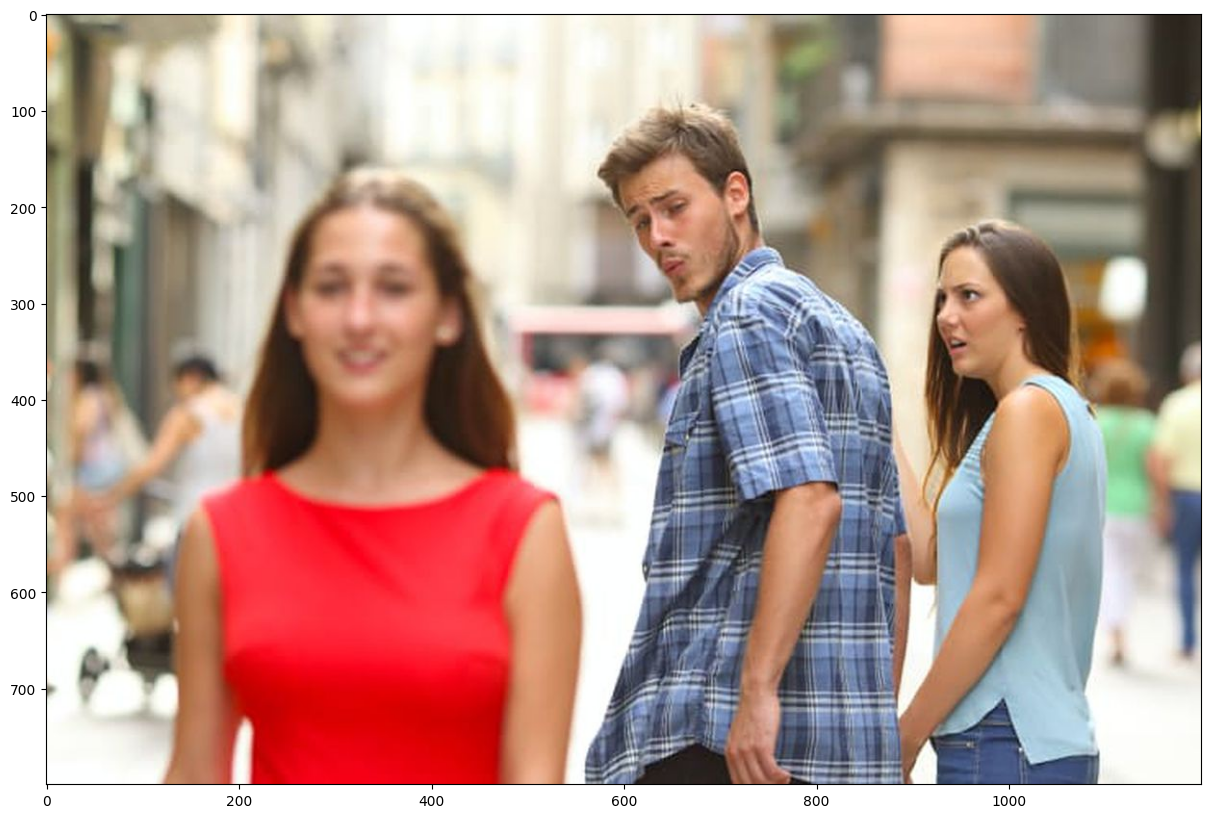

In [8]:
img = cv2.imread('../data/meme.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
plt.imshow(img)

### Step 2

Load the dlib face predictor.

In [9]:
detector = dlib.get_frontal_face_detector()

### Step 3

Run the predictor on your image.

In [10]:
rects = detector(gray, 1)

print('Number of detected faces:', len(rects))
print(rects)
print(rects[0].left)

Number of detected faces: 3
rectangles[[(253, 236) (408, 391)], [(892, 259) (999, 367)], [(569, 153) (698, 282)]]
<bound method PyCapsule.left of rectangle(253,236,408,391)>


### Step 4

Draw bounding boxes around the detected faces and plot the image. Use different colour for each face.

253 236 155 155
892 259 107 108
569 153 129 129


(<Axes: title={'center': 'dlib'}>,
 Text(0.5, 1.0, 'dlib'))

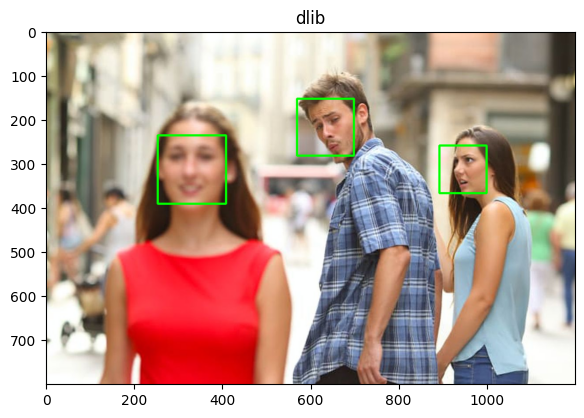

In [ ]:
def rect_to_bb(rect):
    """Coverts dlib rectangle to opencv rectange
    """
    x = rect.left()
    y = rect.top()
    w = rect.right() - x
    h = rect.bottom() - y

    return (x, y, w, h)

def get_detected_faces(img, rects):
    """Draws all detected faces (rectangles) on the image
    """
    result = np.copy(img)
    faces_dlib_img = []
    for rect in rects:    
        x, y, w, h = rect_to_bb(rect)
        print(x, y, w, h)
        cv2.rectangle(result, (x, y), (x+w, y+h), (0, 255, 0), 3)
        faces_dlib_img.append(img[y:y+h, x:x+w, :])
    return result

plt.subplot(122)
plt.imshow(get_detected_faces(img, rects))
plt.title('dlib')

### Step 5 (optional)

Repeat the process with a different and more challenging image (more faces, smaller faces, people with glasses, hats, helmets, etc.). How does the detector perform? Is it robust?

In [12]:
def detect_faces(img_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    detector = dlib.get_frontal_face_detector()
    rects = detector(gray, 1)
    print('Number of detected faces:', len(rects))
    plt.subplot(122)
    plt.imshow(get_detected_faces(img, rects))
    plt.title('Detected faces')

Number of detected faces: 0


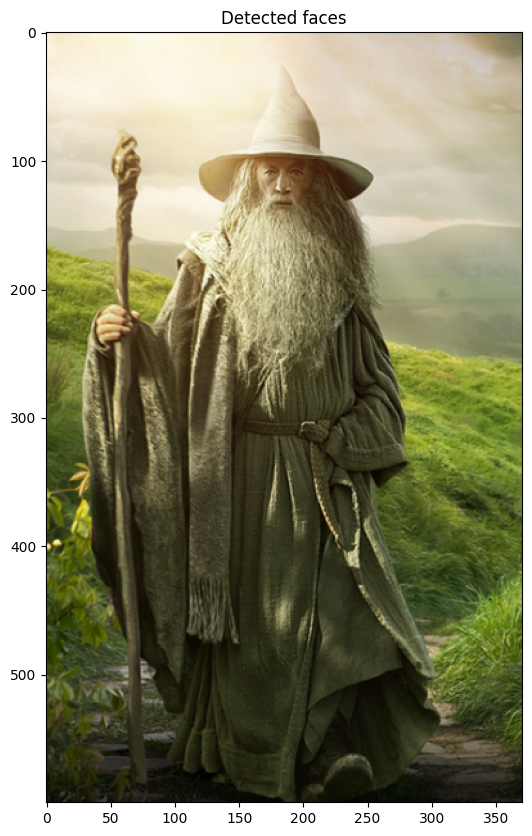

In [14]:
detect_faces("../data/gandalf.png")

Number of detected faces: 1
118 20 52 52


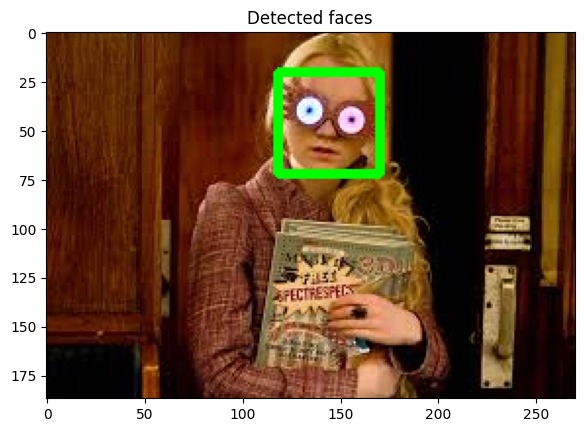

In [17]:
detect_faces("../data/luna_lovegood.jpg")


Number of detected faces: 6
197 53 62 62
31 39 62 62
301 87 62 62
121 108 62 62
432 87 62 62
515 53 62 62


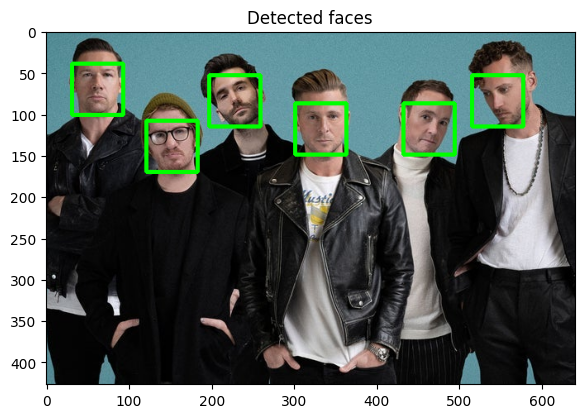

In [18]:
detect_faces("../data/one_republic.jpg")

### Summary

Dlib’s HOG detector is fast on a CPU and works best for clear, front-facing faces, but misses angled or low-light ones. For example, it didn't detect Gandalf's face.